# Sentiment Analysis of Cephalopods – Entry

This notebook demonstrates:
- Video data handling
- Feature extraction
- Visualization
- Behavioral interpretation

In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [29]:
video_path = "../data/octopus_camouflage.mp4"

print("Exists:", os.path.exists(video_path))

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration = total_frames / fps

cap.release()

print(f"FPS: {fps}")
print(f"Resolution: {width} x {height}")
print(f"Duration: {duration:.2f} seconds")

Exists: True
FPS: 29.97002997002997
Resolution: 1080 x 1920
Duration: 11.61 seconds


In [30]:
cap = cv2.VideoCapture(video_path)

motion_values = []
hist_values = []
times = []

prev_gray = None
prev_hist = None

frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    if prev_gray is not None:
        diff = cv2.absdiff(prev_gray, gray)
        motion = np.mean(diff)
        motion_values.append(motion)

    hist = cv2.calcHist([gray], [0], None, [32], [0,256])
    hist = cv2.normalize(hist, hist).flatten()

    if prev_hist is not None:
        change = np.sum(np.abs(hist - prev_hist))
        hist_values.append(change)

    if prev_gray is not None and prev_hist is not None:
        times.append(frame_idx / fps)

    prev_gray = gray
    prev_hist = hist
    frame_idx += 1

cap.release()

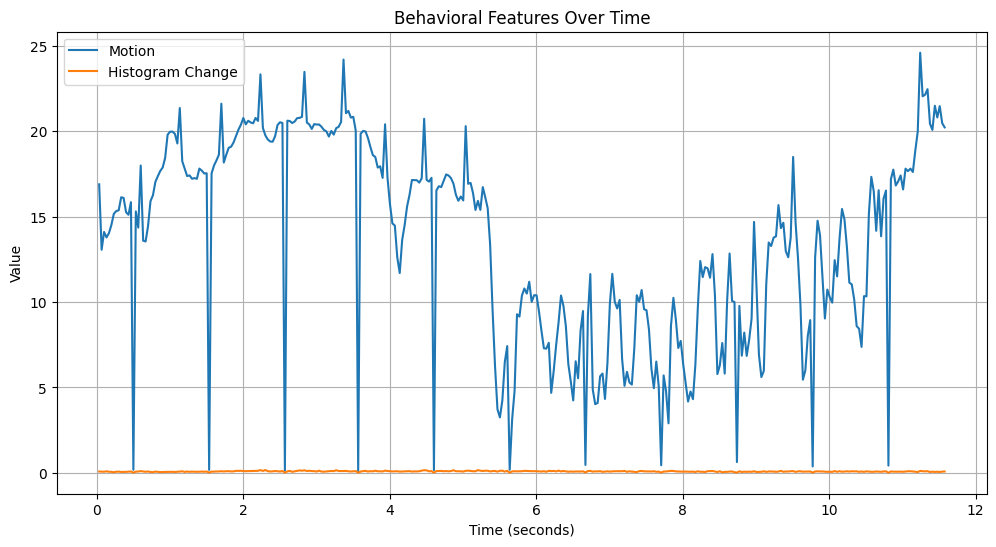

In [31]:
plt.figure(figsize=(12,6))

plt.plot(times, motion_values, label="Motion")
plt.plot(times, hist_values, label="Histogram Change")

plt.xlabel("Time (seconds)")
plt.ylabel("Value")
plt.title("Behavioral Features Over Time")
plt.legend()
plt.grid()

plt.show()

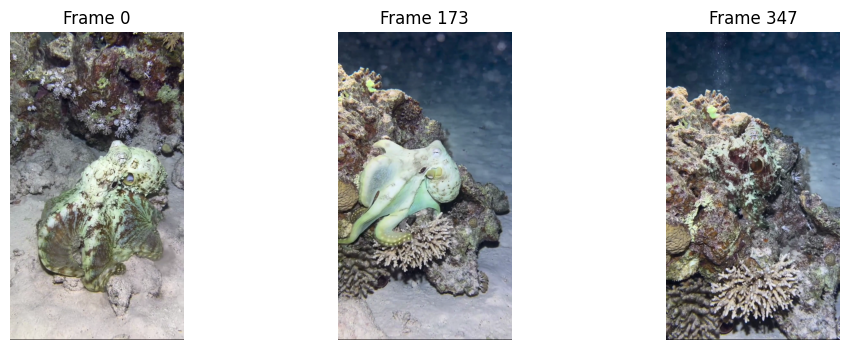

In [32]:
cap = cv2.VideoCapture(video_path)

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
indices = np.linspace(0, total_frames-1, 3, dtype=int)

plt.figure(figsize=(12,4))

for i, idx in enumerate(indices):
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = cap.read()
    if ret:
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        plt.subplot(1,3,i+1)
        plt.imshow(frame)
        plt.title(f"Frame {idx}")
        plt.axis("off")

cap.release()
plt.show()

## Behavioral Interpretation

- High motion values indicate active movement.
- Low motion suggests calm or resting behavior.
- Histogram changes reflect visual variation.

Limitations:
- No posture detection
- Sensitive to lighting
- Cannot infer emotions directly

Future improvements:
- Optical flow
- Contour tracking
- Audio integration